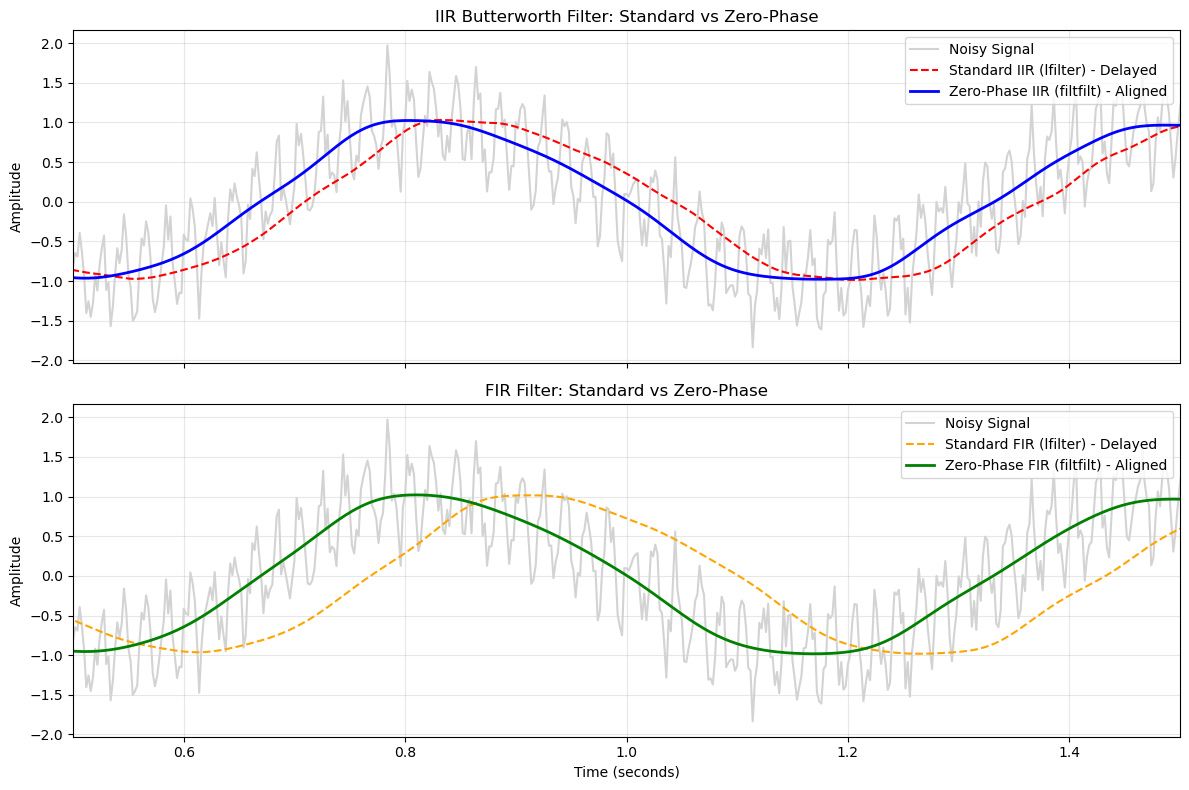

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, firwin, lfilter, filtfilt

def generate_test_signal(fs, duration):
    """Generates a low-frequency physiological-like wave corrupted by high-frequency noise."""
    t = np.arange(0, duration, 1/fs)
    # Primary signal (e.g., 1.5 Hz ~ 90 BPM)
    clean_signal = np.sin(2 * np.pi * 1.5 * t)
    # High-frequency noise (e.g., 50 Hz line noise + random motion artifacts)
    noise = 0.5 * np.sin(2 * np.pi * 50 * t) + 0.2 * np.random.randn(len(t))
    return t, clean_signal + noise

def main():
    # 1. Setup signal parameters
    fs = 500.0  # Sampling frequency (Hz)
    t, noisy_signal = generate_test_signal(fs, duration=2.0)
    
    # Filter requirements
    cutoff = 10.0  # Cutoff frequency (Hz)
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq

    # 2. Design Filters
    # IIR Filter: 4th-order Butterworth
    b_iir, a_iir = butter(4, normal_cutoff, btype='low', analog=False)

    # FIR Filter: Window-based design (Hamming)
    # Using 101 taps (odd number ensures a symmetrical integer delay)
    numtaps = 101
    b_fir = firwin(numtaps, normal_cutoff)
    a_fir = 1.0  # Denominator for FIR is always 1

    # 3. Apply Filters
    # Standard Causal Filtering (introduces phase delay)
    y_iir_standard = lfilter(b_iir, a_iir, noisy_signal)
    y_fir_standard = lfilter(b_fir, a_fir, noisy_signal)

    # Zero-Phase Filtering (acausal, forward-backward, no delay)
    y_iir_zerophase = filtfilt(b_iir, a_iir, noisy_signal)
    y_fir_zerophase = filtfilt(b_fir, a_fir, noisy_signal)

    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Plot IIR Results
    ax1.plot(t, noisy_signal, color='lightgray', label='Noisy Signal')
    ax1.plot(t, y_iir_standard, color='red', linestyle='--', label='Standard IIR (lfilter) - Delayed')
    ax1.plot(t, y_iir_zerophase, color='blue', linewidth=2, label='Zero-Phase IIR (filtfilt) - Aligned')
    ax1.set_title('IIR Butterworth Filter: Standard vs Zero-Phase')
    ax1.set_ylabel('Amplitude')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # Plot FIR Results
    ax2.plot(t, noisy_signal, color='lightgray', label='Noisy Signal')
    ax2.plot(t, y_fir_standard, color='orange', linestyle='--', label='Standard FIR (lfilter) - Delayed')
    ax2.plot(t, y_fir_zerophase, color='green', linewidth=2, label='Zero-Phase FIR (filtfilt) - Aligned')
    ax2.set_title('FIR Filter: Standard vs Zero-Phase')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Amplitude')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    # Zoom in to see the phase shift more clearly
    plt.xlim(0.5, 1.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()